# Unsupervised hierarchical clustering based on chromVAR TF activity

In [4]:
# Set environment 
set.seed(1234)
setwd("~/mouseAD/processed_data/atac/")
library(Signac)
library(Seurat)
library(ggplot2) 
library(dplyr)
library(pheatmap)
library(RColorBrewer) 
library(scales) 
library(viridis)

In [1]:
# Load microglia signac object
mgc <- readRDS("~/mouseAD/processed_data/atac/signac_mgc_combined_chromvar.rds")
mgc

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Signac

Warning message:
“package ‘Signac’ was built under R version 4.3.3”


An object of class Seurat 
269976 features across 40553 samples within 2 assays 
Active assay: peaks (269230 features, 53840 variable features)
 2 layers present: counts, data
 1 other assay present: chromvar
 2 dimensional reductions calculated: lsi, umap

In [2]:
DefaultAssay(mgc) <- "chromvar"
mgc

An object of class Seurat 
269976 features across 40553 samples within 2 assays 
Active assay: chromvar (746 features, 0 variable features)
 1 layer present: data
 1 other assay present: peaks
 2 dimensional reductions calculated: lsi, umap

In [6]:
library(JASPAR2020)
motif_name <- read.table("motif.names.txt", header=T)
head(motif_name)
nrow(motif_name)

,motif,motif.name
,<chr>,<chr>
1,MA1513.1,KLF15
2,MA0598.3,EHF
3,MA0081.2,SPIB
4,MA1564.1,SP9
5,MA0473.3,ELF1
6,MA0746.2,SP3


[1] 746

In [19]:
Idents(mgc) <- "final_cluster"
table(Idents(mgc))


  HMG   DAM   IFN 
19951 19983   619 

In [20]:
# Downsample each subcluster to match the size of the smallest subcluster
# This ensures balanced representation across subclusters for downstream analysis
mgc_sub <- subset(x = mgc, downsample = 619)
mgc_sub

An object of class Seurat 
269976 features across 1857 samples within 2 assays 
Active assay: chromvar (746 features, 0 variable features)
 1 layer present: data
 1 other assay present: peaks
 2 dimensional reductions calculated: lsi, umap

In [21]:
chromvar = data.frame(mgc_sub@assays$chromvar@data)
nrow(chromvar)
length(unique(rownames(chromvar)))

rownames(chromvar) <- motif_name_ordered$motif.name

[1] 746

[1] 746

In [23]:
# Before removing blacklist motif
Blacklist_motif = c()
chromvar_filt = chromvar[!rownames(chromvar) %in% Blacklist_motif,]
chromvar_filt = data.frame(chromvar_filt)

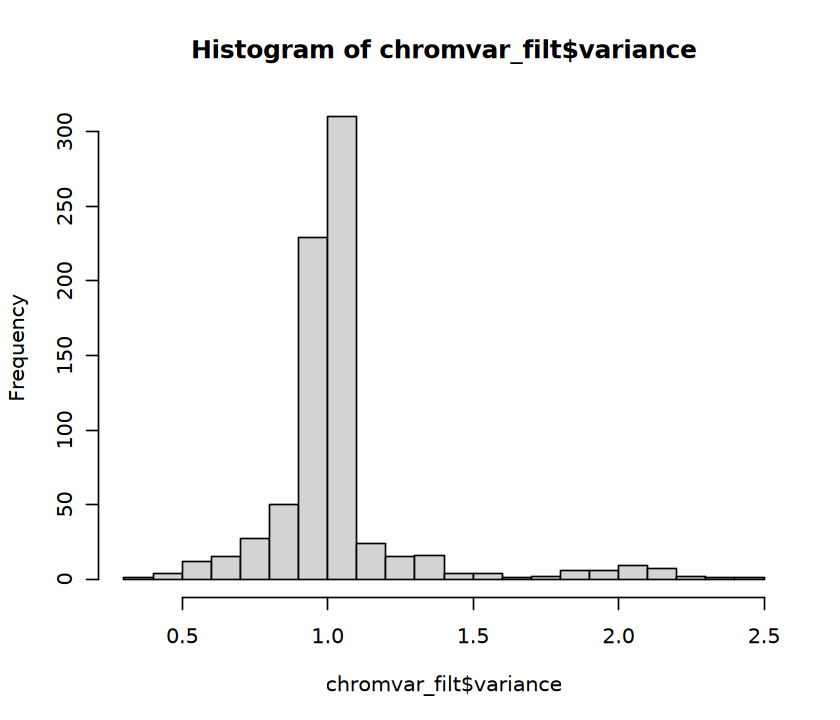

In [24]:
# Calculate variance
library(matrixStats)
chromvar_filt$variance = rowVars(as.matrix(chromvar_filt))
options(repr.plot.width=7, repr.plot.height=6)
hist(chromvar_filt$variance, breaks=20)

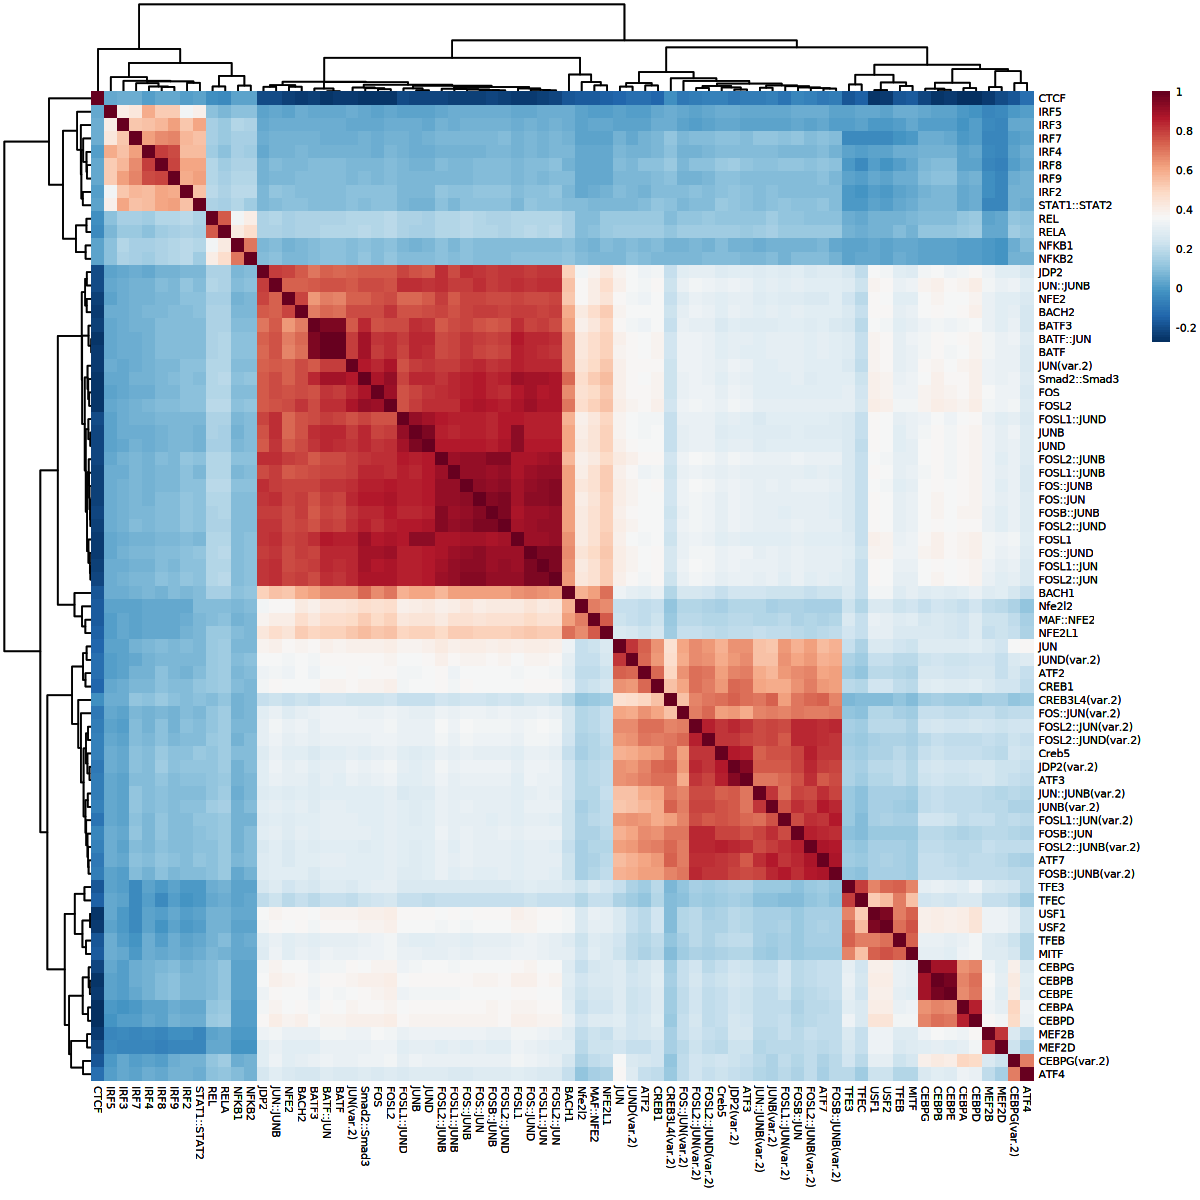

In [26]:
# Filter motifs to retain only the top variable ones
Top_variance = subset(chromvar_filt, chromvar_filt$variance >= 1.2)

# Subset the ChromVAR data frame to retain only the top variable motifs
chromvar_top = subset(chromvar_filt, rownames(chromvar_filt) %in% rownames(Top_variance))

# Remove the column containing variance values from the subsetted ChromVAR data frame
chromvar_top = chromvar_top[,-23666]

# Calculate pairwise correlation between motifs
chromvar_cor=cor(t(chromvar_top))

# Hirarchical clustering and plot the motif correlation heatmap
options(repr.plot.width=10, repr.plot.height=10)
p <- pheatmap(chromvar_cor,color = colorRampPalette(rev(brewer.pal(n = 11, name =
                                                                "RdBu")))(100), border_color = NA, fontsize = 6)
# Display the heatmap
p

In [27]:
motif_list<- rownames(chromvar_cor)[p$tree_row$order]
motif_list

[1] "CTCF"               "IRF5"               "IRF3"              
 [4] "IRF7"               "IRF4"               "IRF8"              
 [7] "IRF9"               "IRF2"               "STAT1::STAT2"      
[10] "REL"                "RELA"               "NFKB1"             
[13] "NFKB2"              "JDP2"               "JUN::JUNB"         
[16] "NFE2"               "BACH2"              "BATF3"             
[19] "BATF::JUN"          "BATF"               "JUN(var.2)"        
[22] "Smad2::Smad3"       "FOS"                "FOSL2"             
[25] "FOSL1::JUND"        "JUNB"               "JUND"              
[28] "FOSL2::JUNB"        "FOSL1::JUNB"        "FOS::JUNB"         
[31] "FOS::JUN"           "FOSB::JUNB"         "FOSL2::JUND"       
[34] "FOSL1"              "FOS::JUND"          "FOSL1::JUN"        
[37] "FOSL2::JUN"         "BACH1"              "Nfe2l2"            
[40] "MAF::NFE2"          "NFE2L1"             "JUN"               
[43] "JUND(var.2)"        "ATF2"               "CREB1"             
[46] "CREB3L4(var.2)"     "FOS::JUN(var.2)"    "FOSL2::JUN(var.2)" 
[49] "FOSL2::JUND(var.2)" "Creb5"              "JDP2(var.2)"       
[52] "ATF3"               "JUN::JUNB(var.2)"   "JUNB(var.2)"       
[55] "FOSL1::JUN(var.2)"  "FOSB::JUN"          "FOSL2::JUNB(var.2)"
[58] "ATF7"               "FOSB::JUNB(var.2)"  "TFE3"              
[61] "TFEC"               "USF1"               "USF2"              
[64] "TFEB"               "MITF"               "CEBPG"             
[67] "CEBPB"              "CEBPE"              "CEBPA"             
[70] "CEBPD"              "MEF2B"              "MEF2D"             
[73] "CEBPG(var.2)"       "ATF4"

In [28]:
# Remove TF motifs that are redundant or highly similar 
# Excluding these prevents them from dominating clustering
start <- match('JDP2', motif_list)
end <- match('FOSB::JUNB(var.2)', motif_list)
blk_list <- motif_list[(start:end)]
blk_list

chromvar_filt = chromvar[!rownames(chromvar) %in% blk_list, ]
chromvar_filt = data.frame(chromvar_filt)
nrow(chromvar_filt)

[1] "JDP2"               "JUN::JUNB"          "NFE2"              
 [4] "BACH2"              "BATF3"              "BATF::JUN"         
 [7] "BATF"               "JUN(var.2)"         "Smad2::Smad3"      
[10] "FOS"                "FOSL2"              "FOSL1::JUND"       
[13] "JUNB"               "JUND"               "FOSL2::JUNB"       
[16] "FOSL1::JUNB"        "FOS::JUNB"          "FOS::JUN"          
[19] "FOSB::JUNB"         "FOSL2::JUND"        "FOSL1"             
[22] "FOS::JUND"          "FOSL1::JUN"         "FOSL2::JUN"        
[25] "BACH1"              "Nfe2l2"             "MAF::NFE2"         
[28] "NFE2L1"             "JUN"                "JUND(var.2)"       
[31] "ATF2"               "CREB1"              "CREB3L4(var.2)"    
[34] "FOS::JUN(var.2)"    "FOSL2::JUN(var.2)"  "FOSL2::JUND(var.2)"
[37] "Creb5"              "JDP2(var.2)"        "ATF3"              
[40] "JUN::JUNB(var.2)"   "JUNB(var.2)"        "FOSL1::JUN(var.2)" 
[43] "FOSB::JUN"          "FOSL2::JUNB(var.2)" "ATF7"              
[46] "FOSB::JUNB(var.2)"

[1] 700

In [29]:
chromvar_filt = chromvar_filt[!rownames(chromvar_filt) == "CTCF", ]
nrow(chromvar_filt)

[1] 699

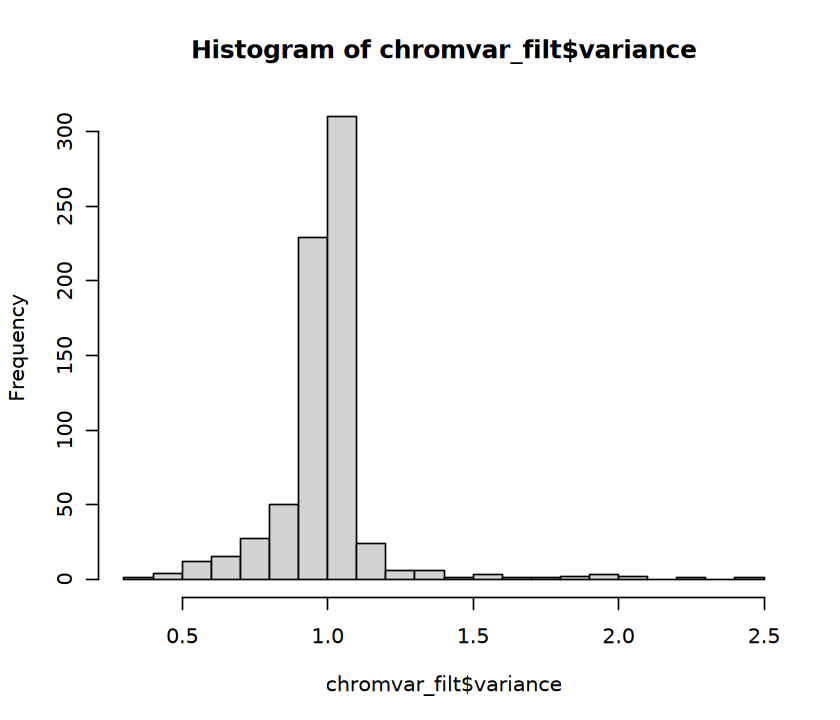

In [30]:
# Calculate variance
chromvar_filt$variance = rowVars(as.matrix(chromvar_filt))
options(repr.plot.width=7, repr.plot.height=6)
hist(chromvar_filt$variance, breaks=20)

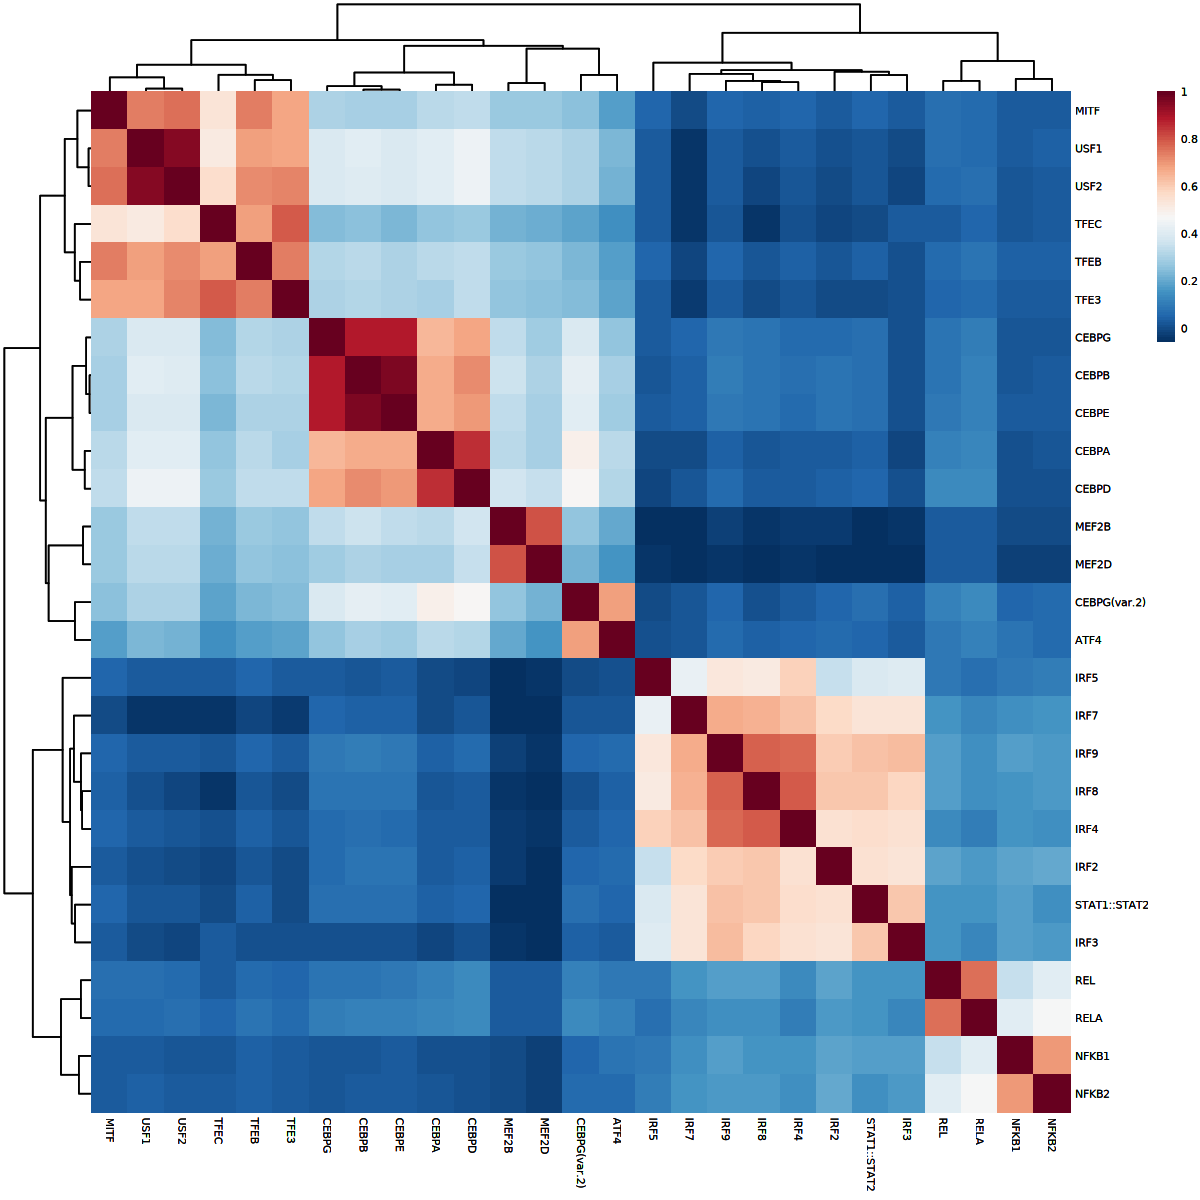

In [32]:
# Filter motifs to retain only the top variable ones
Top_variance = subset(chromvar_filt, chromvar_filt$variance >= 1.2)

# Subset the ChromVAR data frame to retain only the top variable motifs
chromvar_top = subset(chromvar_filt, rownames(chromvar_filt) %in% rownames(Top_variance))

# Remove the column containing variance values from the subsetted ChromVAR data frame
chromvar_top = chromvar_top[,-23666]

# Calculate pairwise correlation between motifs
chromvar_cor=cor(t(chromvar_top))

# Hirarchical clustering and plot the motif correlation heatmap
options(repr.plot.width=10, repr.plot.height=10)
p <- pheatmap(chromvar_cor,color = colorRampPalette(rev(brewer.pal(n = 11, name =
                                                                "RdBu")))(100), border_color = NA, fontsize = 6)
# Display the heatmap
p

Warning message in stat_summary(fun = mean, geom = "line", shape = 18, size = 3, :
"Ignoring unknown parameters: `shape`"
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


png 
  2

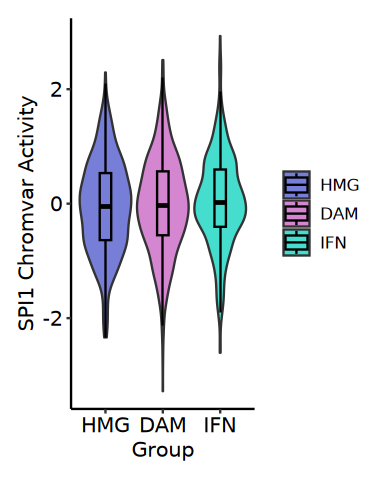

In [117]:
options(repr.plot.width=3.2, repr.plot.height=4)
motif_to_plot = "SPI1"
vln_plot <- VlnPlot(mgc_sub, features = motif_name[motif_name$motif.name == motif_to_plot, ]$motif, 
                    cols = c("#777ED8", "#d486d1", "#45ddce"), 
                    pt.size = 0) + NoLegend() + 
  geom_boxplot(width = 0.2, 
               color = "black", 
               alpha = 0.2, 
               outlier.shape = NA) + 
  stat_summary(fun = mean, 
               geom = "line", 
               shape = 18, 
               size = 3, 
               color = "black") +
  theme_classic() +
  theme(
    text = element_text(color = "black", size=12),       
    axis.title = element_text(color = "black", size=12), 
    axis.text = element_text(color = "black", size=12),  
    plot.title = element_text(color = "black", size=12)  
  ) +
  labs(title = c(),
       x = "Group",
       y = paste0(motif_to_plot, " Chromvar Activity"))
vln_plot

Warning message in stat_summary(fun = mean, geom = "line", shape = 18, size = 3, :
"Ignoring unknown parameters: `shape`"
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


png 
  2

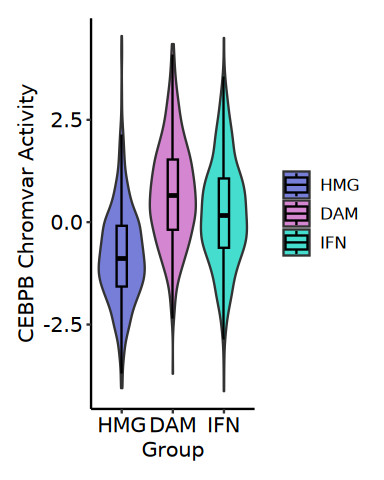

In [118]:
motif_to_plot = "CEBPB"
vln_plot <- VlnPlot(mgc_sub, features = motif_name[motif_name$motif.name == motif_to_plot, ]$motif, 
                    cols = c("#777ED8", "#d486d1", "#45ddce"), 
                    pt.size = 0) + NoLegend() + 
  geom_boxplot(width = 0.2, 
               color = "black", 
               alpha = 0.2, 
               outlier.shape = NA) + 
  stat_summary(fun = mean, 
               geom = "line", 
               shape = 18, 
               size = 3, 
               color = "black") +
  theme_classic() +
  theme(
    text = element_text(color = "black", size=12),       
    axis.title = element_text(color = "black", size=12), 
    axis.text = element_text(color = "black", size=12),  
    plot.title = element_text(color = "black", size=12)  
  ) +
  labs(title = c(),
       x = "Group",
       y = paste0(motif_to_plot, " Chromvar Activity"))
vln_plot

Warning message in stat_summary(fun = mean, geom = "line", shape = 18, size = 3, :
"Ignoring unknown parameters: `shape`"
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


png 
  2

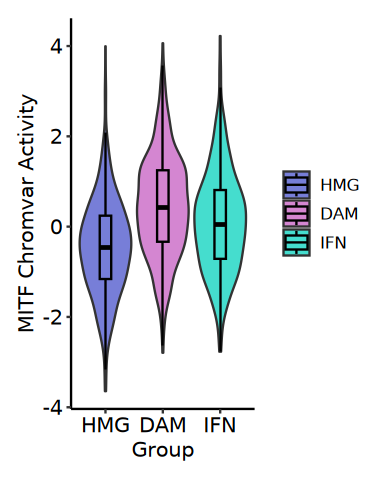

In [119]:
motif_to_plot = "MITF"
vln_plot <- VlnPlot(mgc_sub, features = motif_name[motif_name$motif.name == motif_to_plot, ]$motif, 
                    cols = c("#777ED8", "#d486d1", "#45ddce"), 
                    pt.size = 0) + NoLegend() + 
  geom_boxplot(width = 0.2, 
               color = "black", 
               alpha = 0.2, 
               outlier.shape = NA) + 
  stat_summary(fun = mean, 
               geom = "line", 
               shape = 18, 
               size = 3, 
               color = "black") +
  theme_classic() +
  theme(
    text = element_text(color = "black", size=12),       
    axis.title = element_text(color = "black", size=12), 
    axis.text = element_text(color = "black", size=12),  
    plot.title = element_text(color = "black", size=12)  
  ) +
  labs(title = c(),
       x = "Group",
       y = paste0(motif_to_plot, " Chromvar Activity"))
vln_plot

Warning message in stat_summary(fun = mean, geom = "line", shape = 18, size = 3, :
"Ignoring unknown parameters: `shape`"
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


png 
  2

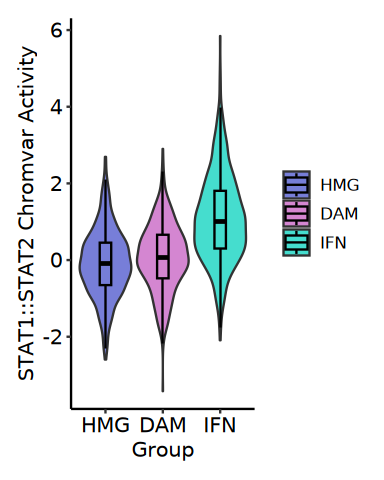

In [122]:
motif_to_plot = "STAT1::STAT2"
vln_plot <- VlnPlot(mgc_sub, features = motif_name[motif_name$motif.name == motif_to_plot, ]$motif, 
                    cols = c("#777ED8", "#d486d1", "#45ddce"), 
                    pt.size = 0) + NoLegend() + 
  geom_boxplot(width = 0.2, 
               color = "black", 
               alpha = 0.2, 
               outlier.shape = NA) + 
  stat_summary(fun = mean, 
               geom = "line", 
               shape = 18, 
               size = 3, 
               color = "black") +
  theme_classic() +
  theme(
    text = element_text(color = "black", size=12),       
    axis.title = element_text(color = "black", size=12), 
    axis.text = element_text(color = "black", size=12),  
    plot.title = element_text(color = "black", size=12)  
  ) +
  labs(title = c(),
       x = "Group",
       y = paste0(motif_to_plot, " Chromvar Activity"))
vln_plot

Warning message in stat_summary(fun = mean, geom = "line", shape = 18, size = 3, :
"Ignoring unknown parameters: `shape`"
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


png 
  2

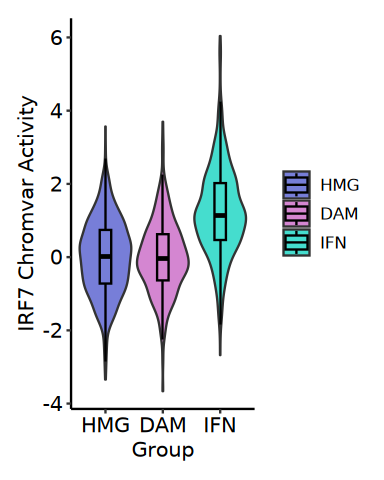

In [121]:
motif_to_plot = "IRF7"
vln_plot <- VlnPlot(mgc_sub, features = motif_name[motif_name$motif.name == motif_to_plot, ]$motif, 
                    cols = c("#777ED8", "#d486d1", "#45ddce"), 
                    pt.size = 0) + NoLegend() + 
  geom_boxplot(width = 0.2, 
               color = "black", 
               alpha = 0.2, 
               outlier.shape = NA) + 
  stat_summary(fun = mean, 
               geom = "line", 
               shape = 18, 
               size = 3, 
               color = "black") +
  theme_classic() +
  theme(
    text = element_text(color = "black", size=12),       
    axis.title = element_text(color = "black", size=12), 
    axis.text = element_text(color = "black", size=12),  
    plot.title = element_text(color = "black", size=12)  
  ) +
  labs(title = c(),
       x = "Group",
       y = paste0(motif_to_plot, " Chromvar Activity"))
vln_plot